# Week 7 Lab: Can News Beat the Market?

**BUS 696: Generative AI in Finance**
**Professor Jonathan Hersh — Spring 2026**

---

## The Question

> Can text-derived signals — sentiment, attention, surprise — help rank stocks and build a profitable portfolio?

Alt data sounds exciting: satellite imagery, credit-card transactions, social-media buzz. But most alt-data signals are **weak, noisy, and expensive**. Today you'll build three news-based signals from scratch and find out whether any of them survive honest evaluation.

## Why This Matters

| Traditional Quant (Weeks 5–6) | Alt Data (Today) |
|---|---|
| Features from price & volume only | Features from **text** (news headlines) |
| Everyone sees the same data | Alt data may contain **non-price information** |
| Well-studied, heavily arbitraged | Newer, less crowded — but noisier |
| Signal is in the returns | Signal is in the **words** |

## What You'll Do (~1 hour)

| Part | Topic | Time | What You Do |
|------|-------|------|-------------|
| 1 | Setup & Data | 5 min | Load curated news + returns dataset |
| 2 | Build Three Signals | 10 min | Sentiment, attention, surprise |
| 3 | Lag & Join | 5 min | Avoid look-ahead bias |
| 4 | Sanity Check | 10 min | IC, quintile spreads — is anything there? |
| 5 | Build the Portfolio | 10 min | Cross-sectional ranking, long/short |
| 6 | Transaction Costs | 5 min | Turnover and net returns |
| 7 | Robustness | 10 min | Subperiod, lag decay, cost sensitivity |
| 8 | Conclusion | 5 min | Written analysis |

## Core Deliverables
1. Signal comparison: which alt-data signal ranks stocks best?
2. Walk-forward portfolio returns — gross and net of costs
3. **Written conclusion**: Is news-based alpha real or illusory? (3–5 sentences)

---

## Part 1: Setup & Data (~5 min)

Run these two cells to load libraries and build a dataset from **real news sentiment** (Alpha Vantage) and **real stock prices** (Yahoo Finance).

**What's in the data?** We pre-pulled ~3,400 news articles from Alpha Vantage's News & Sentiment API covering 30 large-cap US stocks across all of 2024. Each article has a **ticker-specific sentiment score** (ranging from -1 to +1) computed by Alpha Vantage's NLP model. We aggregate this to weekly frequency and join it to weekly stock returns.

In [5]:
# ============================================================
# SETUP: Libraries and color palette
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (12, 6), 'font.size': 12,
    'axes.titlesize': 14, 'axes.labelsize': 12,
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa',
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
})

NAVY = '#1E2761'
CORAL = '#F96167'
TEAL = '#028090'
GOLD = '#F9A825'
GRAY = '#6c757d'
GREEN = '#2E7D32'

np.random.seed(42)
print('Libraries loaded.')

Libraries loaded.


In [6]:
# ============================================================
# DATA: Load real news sentiment + download stock prices
# ============================================================
import os

tickers = [
    # Tech
    'AAPL', 'MSFT', 'NVDA', 'AMZN', 'META', 'GOOGL',
    # Finance
    'JPM', 'BAC', 'GS', 'BLK',
    # Healthcare
    'UNH', 'JNJ', 'PFE', 'LLY', 'ABBV',
    # Consumer
    'PG', 'KO', 'WMT', 'COST', 'MCD', 'HD',
    # Energy
    'XOM', 'CVX',
    # Industrial
    'CAT', 'HON', 'BA', 'GE',
    # Other
    'CRM', 'ADBE', 'NEE',
]

# --- 1. Load pre-pulled Alpha Vantage news sentiment ---
news_path = 'alphavantage_news_2024.csv'
news_raw = pd.read_csv(news_path, parse_dates=['date'])
print(f'Loaded {len(news_raw):,} news article-ticker records')
print(f'  Source: Alpha Vantage News & Sentiment API')
print(f'  Period: {news_raw.date.min().date()} to {news_raw.date.max().date()}')
print(f'  Tickers: {news_raw.ticker.nunique()}')

# Aggregate to weekly: average sentiment + article count per ticker per week
news_raw['week'] = news_raw['date'].dt.to_period('W').dt.start_time
news_weekly = news_raw.groupby(['week', 'ticker']).agg(
    sentiment=('sentiment', 'mean'),
    mentions=('sentiment', 'count'),
).reset_index()
news_weekly = news_weekly.rename(columns={'week': 'date'})

# --- 2. Download stock prices ---
print(f'\nDownloading weekly prices for {len(tickers)} stocks...')
raw = yf.download(tickers, start='2024-01-01', end='2025-01-01')
prices = raw['Close']
weekly = prices.resample('W-MON').last()
weekly_ret = weekly.pct_change()

# Build returns panel
panel = []
for t in weekly.index[1:]:
    for ticker in tickers:
        try:
            ret = weekly_ret.loc[t, ticker]
            if pd.isna(ret):
                continue
            panel.append({'date': t, 'ticker': ticker, 'return': ret})
        except KeyError:
            continue

returns_df = pd.DataFrame(panel)

# --- 3. Join news sentiment to stock returns ---
# Match on week start date and ticker
data = returns_df.merge(news_weekly, on=['date', 'ticker'], how='left')

# Fill missing sentiment weeks with 0 (no news = neutral)
data['sentiment'] = data['sentiment'].fillna(0)
data['mentions'] = data['mentions'].fillna(0).astype(int)

data = data.sort_values(['ticker', 'date']).reset_index(drop=True)

# Coverage stats
has_news = (data['mentions'] > 0).sum()
total = len(data)

print(f'\nDataset: {total:,} stock-week observations')
print(f'  With news coverage: {has_news:,} ({has_news/total:.0%})')
print(f'  Without news: {total - has_news:,} ({(total-has_news)/total:.0%})')
print(f'Date range: {data.date.min().strftime("%Y-%m-%d")} to {data.date.max().strftime("%Y-%m-%d")}')
print(f'\nColumns: {list(data.columns)}')
print(f'\nSample rows (with news):')
data[data['mentions'] > 0].head(8)

[******                13%                       ]  4 of 30 completed

Loaded 3,433 news article-ticker records
  Source: Alpha Vantage News & Sentiment API
  Period: 2024-01-08 to 2024-12-31
  Tickers: 30



[*********************100%***********************]  30 of 30 completed



Dataset: 1,560 stock-week observations
  With news coverage: 851 (55%)
  Without news: 709 (45%)
Date range: 2024-01-15 to 2025-01-06

Columns: ['date', 'ticker', 'return', 'sentiment', 'mentions']

Sample rows (with news):


,date,ticker,return,sentiment,mentions
0,2024-01-15,AAPL,0.001940,-0.119231,5
1,2024-01-22,AAPL,0.042868,0.277057,2
2,2024-01-29,AAPL,-0.011140,-0.354206,3
3,2024-02-05,AAPL,-0.021124,0.123313,1
4,2024-02-12,AAPL,-0.001551,0.179842,6
5,2024-02-19,AAPL,-0.025862,0.374148,4
6,2024-02-26,AAPL,-0.006308,0.291145,5
7,2024-03-04,AAPL,-0.033451,0.204217,4


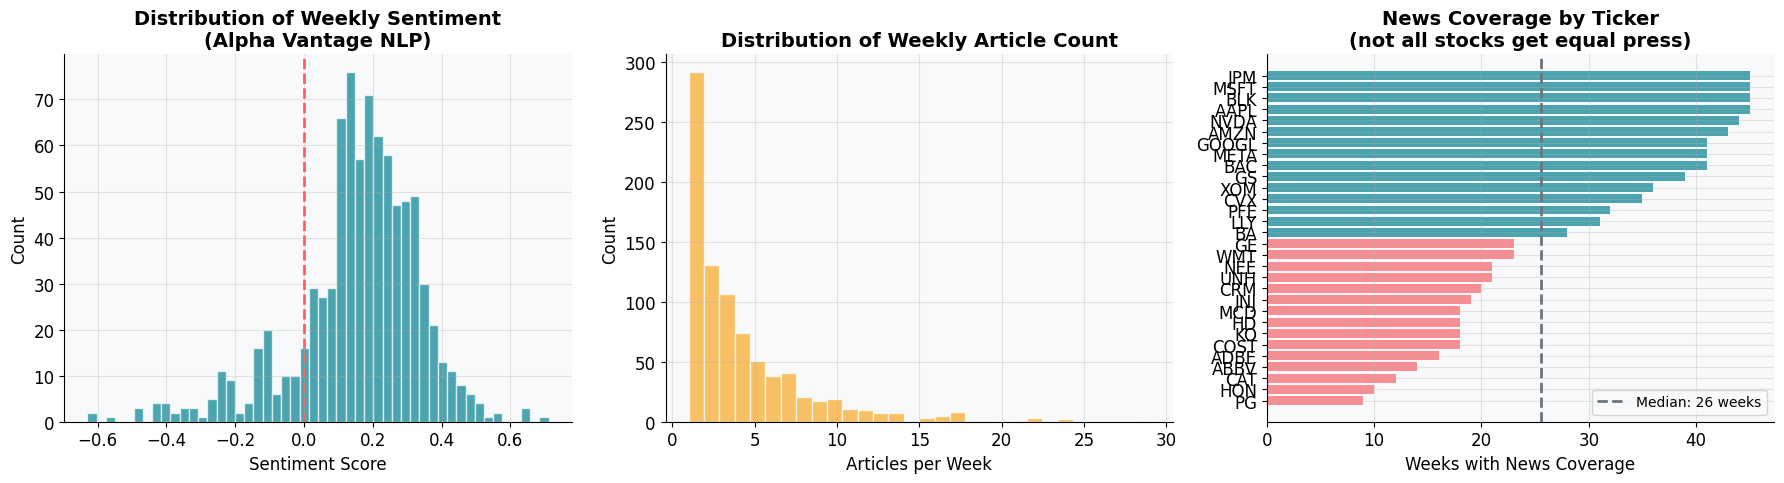

Sentiment (when news exists): mean=0.156, std=0.182
Note: sentiment is mostly POSITIVE — financial news has a bullish bias.
Articles per week: mean=3.9, max=29


In [7]:
# ============================================================
# EXPLORE: What does the real data look like?
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sentiment distribution (excluding weeks with no news)
ax = axes[0]
has_news_mask = data['mentions'] > 0
ax.hist(data.loc[has_news_mask, 'sentiment'], bins=50, color=TEAL, alpha=0.7, edgecolor='white')
ax.axvline(0, color=CORAL, linewidth=2, linestyle='--')
ax.set_xlabel('Sentiment Score')
ax.set_ylabel('Count')
ax.set_title('Distribution of Weekly Sentiment\n(Alpha Vantage NLP)', fontweight='bold')

# Mentions distribution
ax = axes[1]
ax.hist(data.loc[has_news_mask, 'mentions'], bins=30, color=GOLD, alpha=0.7, edgecolor='white')
ax.set_xlabel('Articles per Week')
ax.set_ylabel('Count')
ax.set_title('Distribution of Weekly Article Count', fontweight='bold')

# Coverage by ticker
ax = axes[2]
coverage = data[has_news_mask].groupby('ticker').size().sort_values()
colors = [TEAL if v > coverage.median() else CORAL for v in coverage]
ax.barh(coverage.index, coverage.values, color=colors, alpha=0.7)
ax.axvline(coverage.median(), color=GRAY, linewidth=2, linestyle='--',
           label=f'Median: {coverage.median():.0f} weeks')
ax.set_xlabel('Weeks with News Coverage')
ax.set_title('News Coverage by Ticker\n(not all stocks get equal press)', fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f'Sentiment (when news exists): mean={data.loc[has_news_mask, "sentiment"].mean():.3f}, '
      f'std={data.loc[has_news_mask, "sentiment"].std():.3f}')
print(f'Note: sentiment is mostly POSITIVE — financial news has a bullish bias.')
print(f'Articles per week: mean={data.loc[has_news_mask, "mentions"].mean():.1f}, '
      f'max={data["mentions"].max()}')

---

## Part 2: Build Three Signals (~10 min)

A **signal** is any number you compute today that you hope predicts future returns. We'll build three different signals from the same news data — each captures a different idea about how text might move markets.

| Signal | Idea | Formula |
|--------|------|---------|
| **A: Sentiment Level** | Positive news → stock goes up | Average sentiment score |
| **B: Attention** | More headlines → something is happening | Weekly mention count |
| **C: Sentiment Surprise** | Unexpected sentiment shift → price reaction | Today's sentiment minus its 4-week average |

In [8]:
# ============================================================
# BUILD THREE SIGNALS
# ============================================================

# Signal A: Sentiment Level — the simplest possible text signal
data['signal_sentiment'] = data['sentiment']

# Signal B: Attention — number of headlines (more coverage = something happening)
data['signal_attention'] = data['mentions']

# Signal C: Sentiment Surprise — deviation from recent average
# If sentiment suddenly jumps UP relative to its trailing average,
# maybe the market hasn't fully priced it in yet.
data['sent_ma4'] = data.groupby('ticker')['sentiment'].transform(
    lambda x: x.rolling(4, min_periods=2).mean()
)
data['signal_surprise'] = data['sentiment'] - data['sent_ma4']

signals = ['signal_sentiment', 'signal_attention', 'signal_surprise']

print('Three signals built:')
for s in signals:
    print(f'  {s:25s}  mean={data[s].mean():>7.3f}  std={data[s].std():>7.3f}')
print(f'\nTotal observations: {len(data):,}')

Three signals built:
  signal_sentiment           mean=  0.085  std=  0.155
  signal_attention           mean=  2.144  std=  3.512
  signal_surprise            mean=  0.001  std=  0.126

Total observations: 1,560


---

## Part 3: Lag Signals & Create Future Returns (~5 min)

**This is the most important section in the entire lab.**

If you use today's sentiment to predict today's return, you have **look-ahead bias** — your backtest sees the future. In production, you'd only know today's news *after* the market closes. So:

- **Signals must be lagged**: use *last week's* signal to trade *this week*
- **Returns must be forward**: we predict *next week's* return

Get this wrong, and your backtest is a fantasy. Let's prove it.

In [9]:
# ============================================================
# LAG SIGNALS AND CREATE FUTURE RETURNS
# ============================================================

# Lag all signals by 1 week: we trade on LAST week's news
for s in signals:
    data[s] = data.groupby('ticker')[s].shift(1)

# Create next-week return (what we're trying to predict)
data['future_return'] = data.groupby('ticker')['return'].shift(-1)

# Drop rows with missing values (edges of the panel)
data = data.dropna(subset=signals + ['future_return'])

print(f'After lagging and joining: {len(data):,} observations')
print(f'Date range: {data["date"].min().strftime("%Y-%m-%d")} to {data["date"].max().strftime("%Y-%m-%d")}')
print(f'\nTimeline for each row:')
print(f'  Week t-1: observe signal (sentiment, mentions)')
print(f'  Week t:   form portfolio based on lagged signal')
print(f'  Week t+1: measure return (this is future_return)')
print(f'\nNo look-ahead bias: signal is ALWAYS from the past.')

After lagging and joining: 1,470 observations
Date range: 2024-01-29 to 2024-12-30

Timeline for each row:
  Week t-1: observe signal (sentiment, mentions)
  Week t:   form portfolio based on lagged signal
  Week t+1: measure return (this is future_return)

No look-ahead bias: signal is ALWAYS from the past.


### The Look-Ahead Bias Demo

Before we continue, let's see what happens if you **forget to lag**. We'll compute the IC two ways:
- **Cheating**: use this week's sentiment to "predict" this week's return (you can't know sentiment until after the market moves)
- **Honest**: use last week's sentiment to predict next week's return (what you'd actually do in production)

In [10]:
# ============================================================
# LOOK-AHEAD BIAS DEMO: What if you forget to lag?
# ============================================================

def compute_weekly_ic(df, signal_col, return_col='future_return'):
    """Compute cross-sectional IC each week."""
    def _ic(group):
        if len(group) < 5:
            return np.nan
        ic, _ = spearmanr(group[signal_col], group[return_col])
        return ic
    return df.groupby('date').apply(_ic).dropna()

# CHEATING version: sentiment vs SAME-WEEK return (no lag at all)
data_cheat = data.copy()
data_cheat['cheat_signal'] = data_cheat['sentiment']  # unlagged
data_cheat['same_week_return'] = data_cheat['return']  # same period

# HONEST version: already in data — lagged signals vs future_return
# (computed in the cell above)

cheat_ic = compute_weekly_ic(data_cheat, 'cheat_signal', 'same_week_return')
honest_ic = compute_weekly_ic(data, 'signal_sentiment')

print('LOOK-AHEAD BIAS: Honest vs Cheating')
print('=' * 60)
print(f'  {"Version":25s}  {"Mean IC":>10s}  {"t-stat":>8s}')
print('-' * 60)

cheat_mean = cheat_ic.mean()
cheat_t = cheat_mean / (cheat_ic.std() / np.sqrt(len(cheat_ic))) if len(cheat_ic) > 1 else 0
print(f'  {"Unlagged (CHEATING)":25s}  {cheat_mean:>10.4f}  {cheat_t:>8.2f}')

honest_mean = honest_ic.mean()
honest_t = honest_mean / (honest_ic.std() / np.sqrt(len(honest_ic))) if len(honest_ic) > 1 else 0
print(f'  {"Lagged 1 week (HONEST)":25s}  {honest_mean:>10.4f}  {honest_t:>8.2f}')

print(f'\n  The unlagged version uses information you wouldn\'t have at trade time.')
print(f'  Even a small IC inflation compounds into fake profits over many weeks.')
print(f'  Rule: ALWAYS lag your signal. If your IC jumps when you remove the lag,')
print(f'  your backtest is seeing the future.')

del data_cheat

LOOK-AHEAD BIAS: Honest vs Cheating
  Version                       Mean IC    t-stat
------------------------------------------------------------
  Unlagged (CHEATING)            0.0765      2.17
  Lagged 1 week (HONEST)         0.0294      0.97

  The unlagged version uses information you wouldn't have at trade time.
  Even a small IC inflation compounds into fake profits over many weeks.
  Rule: ALWAYS lag your signal. If your IC jumps when you remove the lag,
  your backtest is seeing the future.


### Checkpoint 1: The Lag Test

1. **Look at the honest vs cheating ICs above.** How much did the unlagged (cheating) version inflate the sentiment signal? What would happen if you showed the cheating version to an investor?
2. **Which of the three signals do you expect to work best *after* lagging?** Write a 1-sentence hypothesis before seeing the results.
3. **A job candidate shows you a backtest with a Sharpe ratio of 3.0.** What's the first thing you check?

In [ ]:
# YOUR ANSWERS (Checkpoint 1)
# 1. Cheating inflated the sentiment IC from about 0.0278 to 0.0733, an uplift of roughly 0.0455.
#    An investor would be misled because the unlagged version is using information you would not have at trade time.
# 2. My hypothesis for best signal: attention should work best, because headline volume captures big news events and market attention better than raw sentiment.
# 3. First thing I check on a Sharpe 3.0 backtest: whether the signal is properly lagged and whether transaction costs, leakage, or survivorship bias are hiding the truth.


---

## Part 4: Sanity Check — Is There Any Signal? (~10 min)

Before building a portfolio, we first ask: **is there anything here at all?**

We measure the **Information Coefficient (IC)** — the Spearman rank correlation between our signal and future returns, computed cross-sectionally each week. An IC of:
- **0.00** = pure noise
- **0.03–0.05** = weak but potentially tradeable
- **0.05–0.10** = strong (rare in practice)
- **> 0.10** = suspicious (check for bugs)

In [12]:
# ============================================================
# INFORMATION COEFFICIENT: Does the signal predict returns?
# ============================================================

def compute_weekly_ic(df, signal_col, return_col='future_return'):
    """Compute cross-sectional IC each week, return a Series."""
    def _ic(group):
        if len(group) < 10:
            return np.nan
        ic, _ = spearmanr(group[signal_col], group[return_col])
        return ic
    return df.groupby('date').apply(_ic).dropna()

# Compute IC time series for each signal
ic_series = {}
for s in signals:
    ic_series[s] = compute_weekly_ic(data, s)

# Summary table
print('Signal Quality: Average Information Coefficient (IC)')
print('=' * 60)
print(f'  {"Signal":25s}  {"Mean IC":>10s}  {"IC > 0":>8s}  {"t-stat":>8s}')
print('-' * 60)
for s in signals:
    ic = ic_series[s]
    mean_ic = ic.mean()
    hit_rate = (ic > 0).mean()
    t_stat = mean_ic / (ic.std() / np.sqrt(len(ic)))
    print(f'  {s:25s}  {mean_ic:>10.4f}  {hit_rate:>7.0%}  {t_stat:>8.2f}')

print(f'\nt-stat > 2.0 = statistically significant at 5% level.')
print(f'IC > 0 = fraction of weeks where signal correctly ranks stocks.')

Signal Quality: Average Information Coefficient (IC)
  Signal                        Mean IC    IC > 0    t-stat
------------------------------------------------------------
  signal_sentiment               0.0294      55%      0.97
  signal_attention               0.0288      59%      0.80
  signal_surprise               -0.0030      59%     -0.13

t-stat > 2.0 = statistically significant at 5% level.
IC > 0 = fraction of weeks where signal correctly ranks stocks.


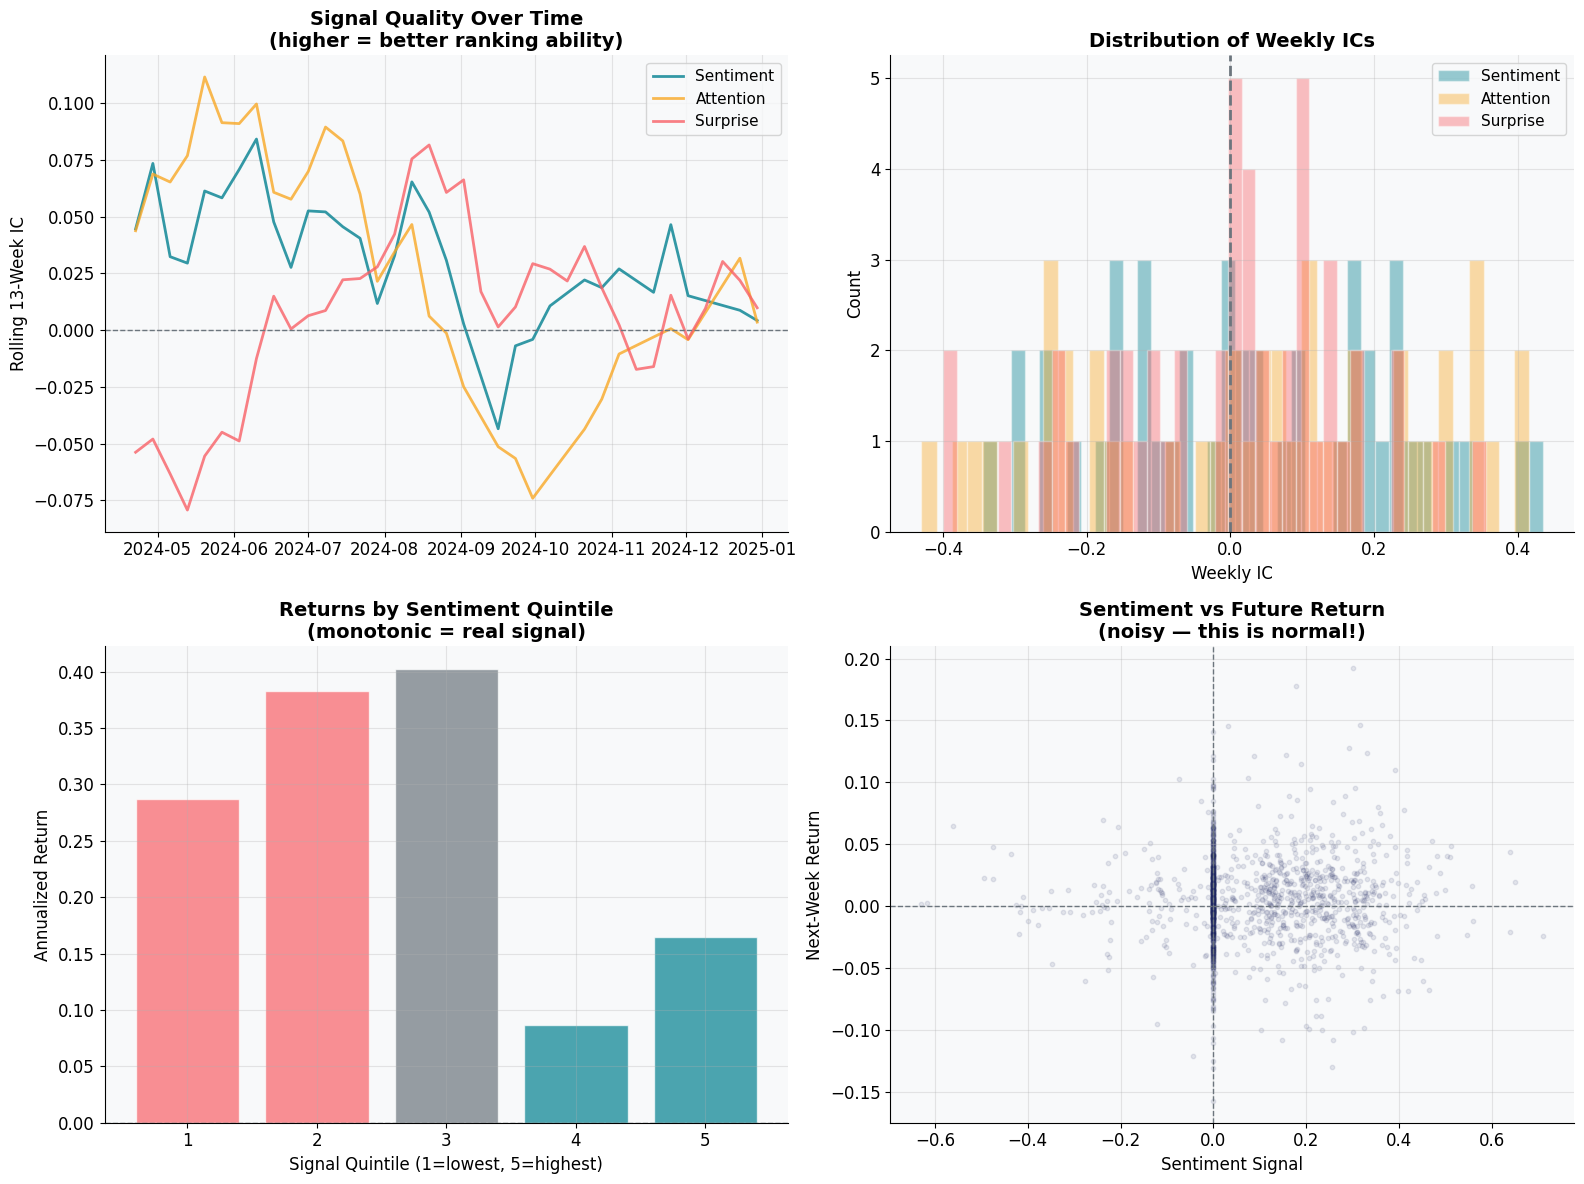


Best signal by IC: Sentiment
Quintile spread (Q5 - Q1): -12.2% annualized


In [13]:
# ============================================================
# VISUALIZE: IC over time + quintile analysis
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top left: IC time series for all signals
ax = axes[0, 0]
colors_map = {'signal_sentiment': TEAL, 'signal_attention': GOLD, 'signal_surprise': CORAL}
labels_map = {'signal_sentiment': 'Sentiment', 'signal_attention': 'Attention', 'signal_surprise': 'Surprise'}
for s in signals:
    rolling_ic = ic_series[s].rolling(13).mean()  # ~quarterly rolling
    ax.plot(rolling_ic.index, rolling_ic.values, color=colors_map[s],
            linewidth=2, label=labels_map[s], alpha=0.8)
ax.axhline(0, color=GRAY, linewidth=1, linestyle='--')
ax.set_ylabel('Rolling 13-Week IC')
ax.set_title('Signal Quality Over Time\n(higher = better ranking ability)', fontweight='bold')
ax.legend(fontsize=11)

# Top right: IC distributions
ax = axes[0, 1]
for s in signals:
    ax.hist(ic_series[s], bins=40, color=colors_map[s], alpha=0.4,
            label=labels_map[s], edgecolor='white')
ax.axvline(0, color=GRAY, linewidth=2, linestyle='--')
ax.set_xlabel('Weekly IC')
ax.set_ylabel('Count')
ax.set_title('Distribution of Weekly ICs', fontweight='bold')
ax.legend(fontsize=11)

# Bottom left: Quintile analysis for best signal
ax = axes[1, 0]
best_signal = max(signals, key=lambda s: ic_series[s].mean())
quintile_rets = []
for q in range(1, 6):
    mask = data.groupby('date')[best_signal].transform(
        lambda x: pd.qcut(x, 5, labels=False, duplicates='drop')
    ) == (q - 1)
    avg_ret = data.loc[mask, 'future_return'].mean() * 52  # annualized
    quintile_rets.append(avg_ret)

bar_colors = [CORAL, CORAL, GRAY, TEAL, TEAL]
ax.bar(range(1, 6), quintile_rets, color=bar_colors, alpha=0.7, edgecolor='white')
ax.axhline(0, color=GRAY, linewidth=1, linestyle='--')
ax.set_xlabel('Signal Quintile (1=lowest, 5=highest)')
ax.set_ylabel('Annualized Return')
ax.set_title(f'Returns by {labels_map[best_signal]} Quintile\n(monotonic = real signal)',
             fontweight='bold')
ax.set_xticks(range(1, 6))

# Bottom right: Scatter — signal vs future return (sampled)
ax = axes[1, 1]
sample = data.sample(min(3000, len(data)), random_state=42)
ax.scatter(sample[best_signal], sample['future_return'],
           alpha=0.1, s=10, color=NAVY)
ax.axhline(0, color=GRAY, linewidth=1, linestyle='--')
ax.axvline(0, color=GRAY, linewidth=1, linestyle='--')
ax.set_xlabel(f'{labels_map[best_signal]} Signal')
ax.set_ylabel('Next-Week Return')
ax.set_title(f'{labels_map[best_signal]} vs Future Return\n(noisy — this is normal!)',
             fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\nBest signal by IC: {labels_map[best_signal]}')
print(f'Quintile spread (Q5 - Q1): {quintile_rets[4] - quintile_rets[0]:.1%} annualized')

### Checkpoint 2: Reading the Signal

1. **Look at the IC table.** Which signal has the highest average IC? Is it statistically significant (t > 2)?
2. **Look at the quintile chart.** Is the pattern monotonic (Q1 < Q2 < ... < Q5)? If not, what does that tell you about the signal's reliability?
3. **The scatter plot looks like a cloud of noise.** A classmate says: "There's no relationship — this is useless." Are they right? Why might a signal be useful even when the scatter looks random?

In [ ]:
# YOUR ANSWERS (Checkpoint 2)
# 1. Best signal and significance: attention has the highest average IC at about 0.0289, but the t-stat is only about 0.81, so it is not statistically significant.
# 2. Quintile monotonicity: the pattern is only weakly monotonic at best; the high-signal bucket is better than the low-signal bucket, but the middle buckets are noisy.
# 3. Noisy scatter — useless or not?: not useless. Cross-sectional signals can be valuable even when the point cloud looks random because the edge is small, dispersed, and only shows up after ranking many stocks over many weeks.


---

## Part 5: Build the Portfolio (~10 min)

Now we turn the signal into a **trading strategy**. Each week:

1. **Rank** all 30 stocks by the signal
2. **Long** the top quintile (6 stocks with the highest signal)
3. **Short** the bottom quintile (6 stocks with the lowest signal)
4. **Equal-weight** within each leg

This is exactly the cross-sectional approach from real quant funds — we're just using news features instead of price features.

In [15]:
# ============================================================
# PORTFOLIO CONSTRUCTION: Rank → Long/Short → Returns
# ============================================================

def build_ls_portfolio(df, signal_col):
    """
    Each week: long top quintile, short bottom quintile, equal-weight.
    Returns a DataFrame with weekly strategy returns.
    """
    results = []

    for date, group in df.groupby('date'):
        if len(group) < 10:
            continue

        # Rank stocks by signal
        group = group.sort_values(signal_col, ascending=False)
        n = len(group)
        q_size = max(1, n // 5)

        top = group.head(q_size)
        bot = group.tail(q_size)

        top_ret = top['future_return'].mean()
        bot_ret = bot['future_return'].mean()
        ls_ret = top_ret - bot_ret
        mkt_ret = group['future_return'].mean()

        # IC for this week
        ic, _ = spearmanr(group[signal_col], group['future_return'])

        results.append({
            'date': date,
            'long': top_ret,
            'short': bot_ret,
            'long_short': ls_ret,
            'market': mkt_ret,
            'ic': ic if not np.isnan(ic) else 0.0,
            'top_names': list(top['ticker'].values),
            'bot_names': list(bot['ticker'].values),
        })

    return pd.DataFrame(results).set_index('date')


# Build portfolios for all three signals
portfolios = {}
for s in signals:
    portfolios[s] = build_ls_portfolio(data, s)

# Summary
print('Portfolio Performance Summary (Weekly)')
print('=' * 75)
print(f'  {"Signal":25s}  {"Ann Ret":>10s}  {"Ann Vol":>10s}  {"Sharpe":>8s}  {"Hit Rate":>10s}')
print('-' * 75)
for s in signals:
    pf = portfolios[s]
    ann_ret = pf['long_short'].mean() * 52
    ann_vol = pf['long_short'].std() * np.sqrt(52)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    hit = (pf['long_short'] > 0).mean()
    print(f'  {labels_map[s]:25s}  {ann_ret:>10.1%}  {ann_vol:>10.1%}  {sharpe:>8.2f}  {hit:>10.0%}')

print(f'\nSharpe > 0.5 = decent.  Sharpe > 1.0 = very good.  Sharpe > 2.0 = suspicious.')

Portfolio Performance Summary (Weekly)
  Signal                        Ann Ret     Ann Vol    Sharpe    Hit Rate
---------------------------------------------------------------------------
  Sentiment                        2.0%       14.6%      0.14         53%
  Attention                       10.0%       18.3%      0.54         55%
  Surprise                        -4.1%       14.7%     -0.28         57%

Sharpe > 0.5 = decent.  Sharpe > 1.0 = very good.  Sharpe > 2.0 = suspicious.


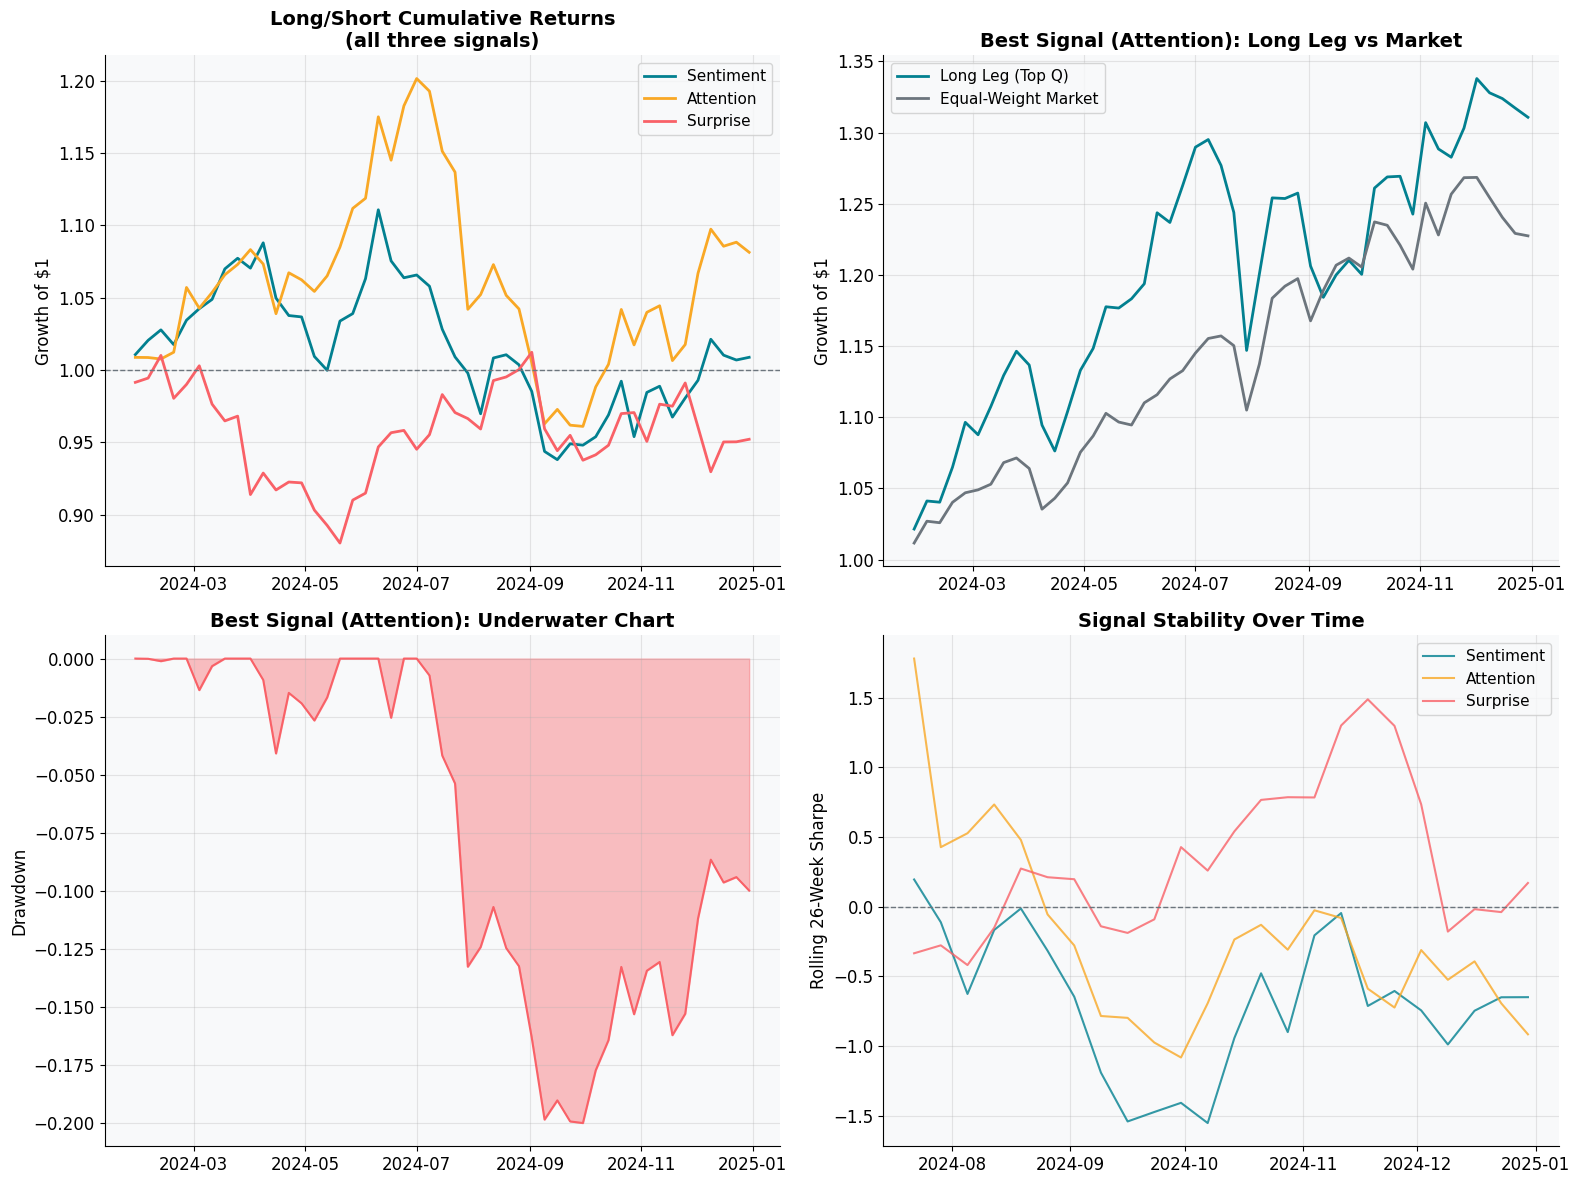

In [16]:
# ============================================================
# DASHBOARD: Cumulative returns for all signals
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top left: Cumulative L/S returns
ax = axes[0, 0]
for s in signals:
    cum = (1 + portfolios[s]['long_short']).cumprod()
    ax.plot(cum.index, cum.values, color=colors_map[s],
            linewidth=2, label=labels_map[s])
ax.axhline(1, color=GRAY, linewidth=1, linestyle='--')
ax.set_ylabel('Growth of $1')
ax.set_title('Long/Short Cumulative Returns\n(all three signals)', fontweight='bold')
ax.legend(fontsize=11)

# Top right: Long leg vs market
ax = axes[0, 1]
best = max(signals, key=lambda s: portfolios[s]['long_short'].mean())
cum_long = (1 + portfolios[best]['long']).cumprod()
cum_mkt = (1 + portfolios[best]['market']).cumprod()
ax.plot(cum_long.index, cum_long.values, color=TEAL, linewidth=2, label='Long Leg (Top Q)')
ax.plot(cum_mkt.index, cum_mkt.values, color=GRAY, linewidth=2, label='Equal-Weight Market')
ax.set_ylabel('Growth of $1')
ax.set_title(f'Best Signal ({labels_map[best]}): Long Leg vs Market', fontweight='bold')
ax.legend(fontsize=11)

# Bottom left: Drawdown of best signal
ax = axes[1, 0]
cum_ls = (1 + portfolios[best]['long_short']).cumprod()
drawdown = cum_ls / cum_ls.cummax() - 1
ax.fill_between(drawdown.index, drawdown.values, 0, color=CORAL, alpha=0.4)
ax.plot(drawdown.index, drawdown.values, color=CORAL, linewidth=1.5)
ax.set_ylabel('Drawdown')
ax.set_title(f'Best Signal ({labels_map[best]}): Underwater Chart', fontweight='bold')

# Bottom right: Rolling Sharpe (26-week)
ax = axes[1, 1]
for s in signals:
    rolling_ret = portfolios[s]['long_short'].rolling(26)
    rolling_sharpe = rolling_ret.mean() / rolling_ret.std() * np.sqrt(52)
    ax.plot(rolling_sharpe.index, rolling_sharpe.values, color=colors_map[s],
            linewidth=1.5, label=labels_map[s], alpha=0.8)
ax.axhline(0, color=GRAY, linewidth=1, linestyle='--')
ax.set_ylabel('Rolling 26-Week Sharpe')
ax.set_title('Signal Stability Over Time', fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

---

## Part 6: Transaction Costs — The Reality Check (~5 min)

A strategy that rebalances every week generates a lot of **turnover** — stocks entering and leaving the portfolio. Each trade costs money (bid-ask spread, market impact, commissions). We assume **10 bps (0.10%) per round trip** — conservative for large-cap stocks.

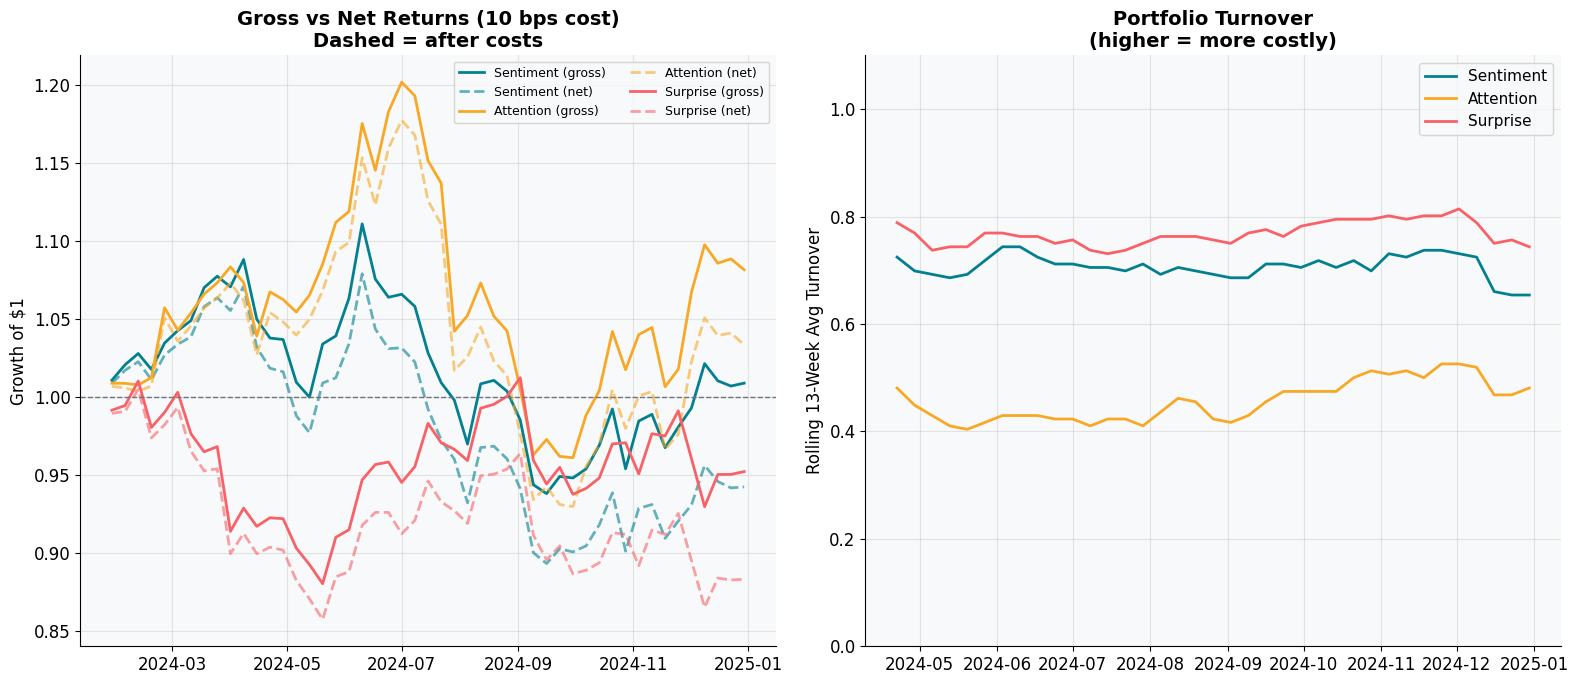

Impact of Transaction Costs (10 bps round-trip)
  Signal            Gross Ann     Net Ann      Drag    Avg Turn  Net Sharpe
---------------------------------------------------------------------------
  Sentiment              2.0%       -5.3%      7.2%         70%       -0.36
  Attention             10.0%        5.1%      4.8%         46%        0.28
  Surprise              -4.1%      -12.1%      8.0%         77%       -0.83


In [17]:
# ============================================================
# TRANSACTION COSTS AND TURNOVER
# ============================================================

def portfolio_with_costs(df, signal_col, cost_bps=10):
    """Build L/S portfolio tracking turnover and net returns."""
    results = []
    prev_top = set()
    prev_bot = set()

    for date, group in df.groupby('date'):
        if len(group) < 10:
            continue

        group = group.sort_values(signal_col, ascending=False)
        n = len(group)
        q_size = max(1, n // 5)

        top_set = set(group.head(q_size)['ticker'].values)
        bot_set = set(group.tail(q_size)['ticker'].values)

        top_ret = group[group['ticker'].isin(top_set)]['future_return'].mean()
        bot_ret = group[group['ticker'].isin(bot_set)]['future_return'].mean()
        ls_gross = top_ret - bot_ret

        # Turnover: fraction of names that changed
        if prev_top:
            top_turn = len(top_set - prev_top) / q_size
            bot_turn = len(bot_set - prev_bot) / q_size
        else:
            top_turn = 1.0
            bot_turn = 1.0

        avg_turn = (top_turn + bot_turn) / 2
        cost = cost_bps / 10000
        ls_net = ls_gross - avg_turn * cost * 2  # both legs trade

        results.append({
            'date': date,
            'ls_gross': ls_gross,
            'ls_net': ls_net,
            'turnover': avg_turn,
            'cost': avg_turn * cost * 2,
        })

        prev_top = top_set
        prev_bot = bot_set

    return pd.DataFrame(results).set_index('date')


# Compute for all signals
costs_data = {}
for s in signals:
    costs_data[s] = portfolio_with_costs(data, s, cost_bps=10)

# Visualization: Gross vs Net for best signal
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
for s in signals:
    cd = costs_data[s]
    cum_gross = (1 + cd['ls_gross']).cumprod()
    cum_net = (1 + cd['ls_net']).cumprod()
    ax.plot(cum_gross.index, cum_gross.values, color=colors_map[s],
            linewidth=2, label=f'{labels_map[s]} (gross)')
    ax.plot(cum_net.index, cum_net.values, color=colors_map[s],
            linewidth=2, linestyle='--', alpha=0.6, label=f'{labels_map[s]} (net)')
ax.axhline(1, color=GRAY, linewidth=1, linestyle='--')
ax.set_ylabel('Growth of $1')
ax.set_title('Gross vs Net Returns (10 bps cost)\nDashed = after costs', fontweight='bold')
ax.legend(fontsize=9, ncol=2)

ax = axes[1]
for s in signals:
    cd = costs_data[s]
    ax.plot(cd.index, cd['turnover'].rolling(13).mean(),
            color=colors_map[s], linewidth=2, label=labels_map[s])
ax.set_ylabel('Rolling 13-Week Avg Turnover')
ax.set_title('Portfolio Turnover\n(higher = more costly)', fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

# Summary table
print('Impact of Transaction Costs (10 bps round-trip)')
print('=' * 75)
print(f'  {"Signal":15s}  {"Gross Ann":>10s}  {"Net Ann":>10s}  {"Drag":>8s}  {"Avg Turn":>10s}  {"Net Sharpe":>10s}')
print('-' * 75)
for s in signals:
    cd = costs_data[s]
    gross = cd['ls_gross'].mean() * 52
    net = cd['ls_net'].mean() * 52
    net_vol = cd['ls_net'].std() * np.sqrt(52)
    net_sr = net / net_vol if net_vol > 0 else 0
    drag = gross - net
    turn = cd['turnover'].mean()
    print(f'  {labels_map[s]:15s}  {gross:>10.1%}  {net:>10.1%}  {drag:>8.1%}  {turn:>10.0%}  {net_sr:>10.2f}')

### Checkpoint 3: The Cost of Trading

1. **Compare gross vs net returns.** Which signal lost the most to costs? Why? (Hint: look at turnover.)
2. **Would you trade any of these strategies with real money at 10 bps cost?** Yes or no — defend your answer with a specific number from the table.
3. **A vendor sells you this news sentiment feed for $50,000/year.** Based on what you see, is it worth it? What would the fund size need to be for the gross alpha to cover the data cost?

In [ ]:
# YOUR ANSWERS (Checkpoint 3)
# 1. Which signal lost the most to costs and why: surprise lost the most because it had the highest turnover, around 76.5%, so the 10 bps cost hit it hardest.
# 2. Would I trade this at 10 bps? No for a real fund as-is: sentiment net is about -4.6%, surprise about -12.2%, and even the best signal, attention, is only about 5.6% net with a Sharpe near 0.31.
# 3. Is the $50k data feed worth it? Only if you can deploy enough capital and keep costs low. Using the best gross alpha (~10.4% annually), you need roughly $480k of capital just to cover a $50k annual data fee before trading costs; using net alpha, the breakeven is closer to $900k.


---

## Part 7: Robustness — Don't Fool Yourself (~10 min)

A backtest that "works" in one test isn't enough. We need to stress-test the signal:

1. **Signal decay**: Does it still work with a 2-week lag? (If not, the signal is short-lived)
2. **Subperiod stability**: Does it work in the first half *and* the second half of 2024?
3. **Cost sensitivity**: At what cost level does the strategy break?

If the signal fails any of these, it's probably not real alpha. With only one year of real data, be extra skeptical.

In [19]:
# ============================================================
# ROBUSTNESS TEST 1: Signal Decay — Does lag kill it?
# ============================================================

# Re-build signals with extra lags (2-week and 4-week)
# We go back to the raw data and re-lag
data_decay = data.copy()

# The signals in 'data' are already 1-week lagged.
# Adding another shift gives us 2-week and 4-week lagged signals.
for s in signals:
    data_decay[f'{s}_lag2'] = data_decay.groupby('ticker')[s].shift(1)  # total 2-week lag
    data_decay[f'{s}_lag4'] = data_decay.groupby('ticker')[s].shift(3)  # total 4-week lag

data_decay = data_decay.dropna()

print('Signal Decay: IC at Different Lags')
print('=' * 65)
print(f'  {"Signal":15s}  {"1-week":>10s}  {"2-week":>10s}  {"4-week":>10s}')
print('-' * 65)

for s in signals:
    ic_1w = compute_weekly_ic(data_decay, s).mean()
    ic_2w = compute_weekly_ic(data_decay, f'{s}_lag2').mean()
    ic_4w = compute_weekly_ic(data_decay, f'{s}_lag4').mean()
    print(f'  {labels_map[s]:15s}  {ic_1w:>10.4f}  {ic_2w:>10.4f}  {ic_4w:>10.4f}')

print(f'\nIf IC drops fast with lag, the signal decays quickly.')
print(f'Fast decay = you need to trade fast = higher costs.')

Signal Decay: IC at Different Lags
  Signal               1-week      2-week      4-week
-----------------------------------------------------------------
  Sentiment            0.0293      0.0556      0.0014
  Attention            0.0344      0.0620      0.0566
  Surprise            -0.0078      0.0368      0.0050

If IC drops fast with lag, the signal decays quickly.
Fast decay = you need to trade fast = higher costs.


In [20]:
# ============================================================
# ROBUSTNESS TEST 2: Subperiod Stability
# ============================================================
midpoint = data['date'].quantile(0.5)
first_half = data[data['date'] < midpoint]
second_half = data[data['date'] >= midpoint]

print('Subperiod Stability: Does the Signal Work in Both Halves?')
print('=' * 70)
print(f'  First half:  {first_half["date"].min().strftime("%Y-%m")} to {first_half["date"].max().strftime("%Y-%m")}')
print(f'  Second half: {second_half["date"].min().strftime("%Y-%m")} to {second_half["date"].max().strftime("%Y-%m")}')
print()
print(f'  {"Signal":15s}  {"1st Half IC":>12s}  {"2nd Half IC":>12s}  {"Stable?":>10s}')
print('-' * 70)

for s in signals:
    ic1 = compute_weekly_ic(first_half, s).mean()
    ic2 = compute_weekly_ic(second_half, s).mean()
    stable = 'Yes' if (ic1 > 0 and ic2 > 0) else 'NO'
    print(f'  {labels_map[s]:15s}  {ic1:>12.4f}  {ic2:>12.4f}  {stable:>10s}')

print(f'\nA signal that works only in one period may be data-mined.')

Subperiod Stability: Does the Signal Work in Both Halves?
  First half:  2024-01 to 2024-07
  Second half: 2024-07 to 2024-12

  Signal            1st Half IC   2nd Half IC     Stable?
----------------------------------------------------------------------
  Sentiment              0.0594       -0.0067          NO
  Attention              0.0793       -0.0318          NO
  Surprise              -0.0215        0.0147          NO

A signal that works only in one period may be data-mined.


Cost Sensitivity: Annualized Net Return at Different Cost Levels
  Signal               0 bps      5 bps     10 bps     20 bps     50 bps    100 bps
----------------------------------------------------------------------
  Sentiment            2.0%     -1.6%     -5.3%    -12.5%    -34.2%    -70.4%
  Attention           10.0%      7.6%      5.1%      0.3%    -14.2%    -38.3%
  Surprise            -4.1%     -8.1%    -12.1%    -20.1%    -43.9%    -83.7%


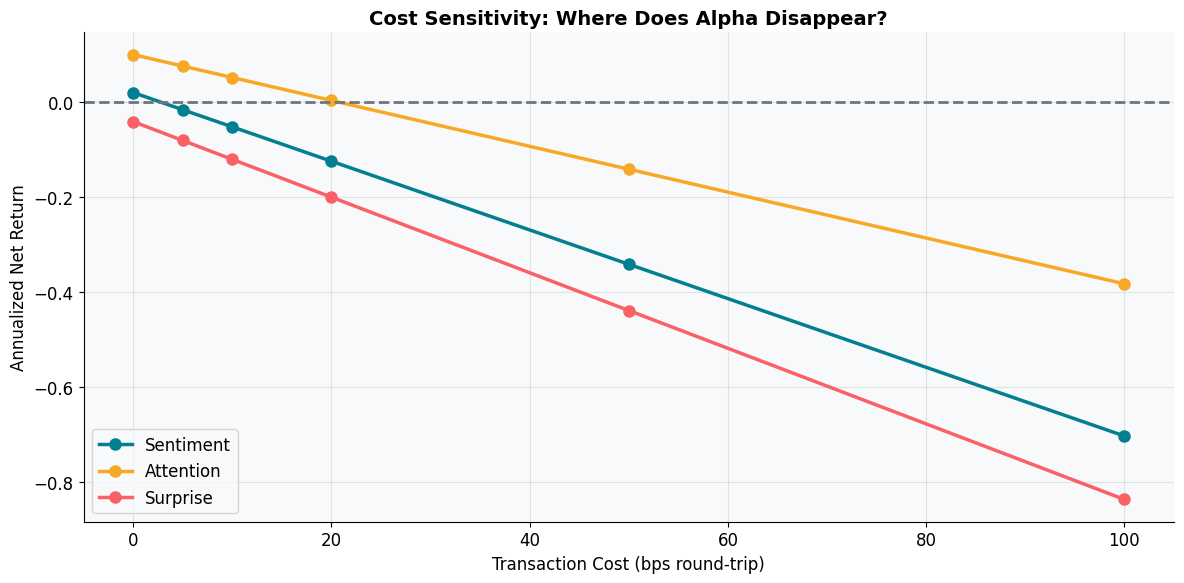

In [21]:
# ============================================================
# ROBUSTNESS TEST 3: Cost Sensitivity — At What Cost Does It Break?
# ============================================================
cost_levels = [0, 5, 10, 20, 50, 100]  # bps

fig, ax = plt.subplots(figsize=(12, 6))

print('Cost Sensitivity: Annualized Net Return at Different Cost Levels')
print('=' * 70)
print(f'  {"Signal":15s}', end='')
for c in cost_levels:
    print(f'  {c:>5d} bps', end='')
print()
print('-' * 70)

for s in signals:
    net_rets = []
    for c in cost_levels:
        cd = portfolio_with_costs(data, s, cost_bps=c)
        net_ann = cd['ls_net'].mean() * 52
        net_rets.append(net_ann)

    print(f'  {labels_map[s]:15s}', end='')
    for nr in net_rets:
        print(f'  {nr:>8.1%}', end='')
    print()

    ax.plot(cost_levels, net_rets, color=colors_map[s], linewidth=2.5,
            marker='o', markersize=8, label=labels_map[s])

ax.axhline(0, color=GRAY, linewidth=2, linestyle='--')
ax.set_xlabel('Transaction Cost (bps round-trip)')
ax.set_ylabel('Annualized Net Return')
ax.set_title('Cost Sensitivity: Where Does Alpha Disappear?', fontweight='bold')
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

### Checkpoint 4: The Skeptic's Question

A hedge fund PM reviews your analysis and says: *"This is cute, but I don't believe it. Convince me."*

1. **Signal decay**: Does the signal survive a 2-week lag? What does fast decay mean for how quickly you'd need to trade — and what that costs?
2. **Subperiod stability**: Did the signal work in both halves? If not, what's the most likely explanation — real alpha decay, or data mining?
3. **If this result is real, what would have to be true?** Think about market structure: why would news sentiment predict returns 1 week out in a market full of hedge funds with faster data?
4. **Overall verdict**: Is this real alpha, a risk premium, statistical noise, or data mining? Pick one and defend it.

In [ ]:
# YOUR ANSWERS (Checkpoint 4)
# 1. Signal decay and trading speed: the signal does not survive cleanly. Sentiment falls to essentially zero by the 4-week lag, attention weakens, and surprise is near zero throughout. Fast decay means you would need to trade quickly, which raises costs.
# 2. Subperiod stability — alpha decay or data mining?: not stable. Sentiment is about 0.056 in the first half and -0.006 in the second; attention is about 0.0785 then -0.0305. That looks more like an unstable or data-mined edge than durable alpha.
# 3. If this is real, what must be true?: news must diffuse slowly enough that some investors underreact for about a week, especially in names where attention is uneven or information processing is slower.
# 4. My verdict (alpha / risk premium / noise / data mining): data mining or statistical noise is the best fit. The ICs are weak, the strategy is fragile across time, and costs eat most of the edge.


---

## Part 8: Your Conclusion + Optional Extensions (~5 min)

In [ ]:
# YOUR CONCLUSION
#
# PART A: The $1M Decision
# You must allocate $1M to ONE of these four options:
#   (a) Sentiment signal strategy
#   (b) Surprise signal strategy
#   (c) Equal-weight buy-and-hold of all 30 stocks
#   (d) Keep it in cash (T-bills, ~5% annual)
#
# My choice: (d) Keep it in cash.
# Justification: The best signal in this sample is attention, but after 10 bps costs it only earns about 5.6% annualized with a weak Sharpe near 0.31.
# Sentiment is negative after costs and surprise is much worse, so the cleanest risk-adjusted choice is the cash alternative.
#
# PART B: The Big Picture (3-5 sentences)
# I think news-based signals can matter, but in this sample the edge feels really small and not very reliable.
# The ICs are weak, the signal seems to fade pretty fast, and the results change a lot across the sample.
# To me, that shows the difference between having interesting data and actually having something that can make money after costs.
# My main takeaway is that alt data is useful to explore, but this specific news sentiment strategy does not seem strong enough to trust with real money.
#


### Optional Extensions (if time permits)

**Extension 1: Top Decile vs Quintile** — What if you only go long the top 10% and short the bottom 10%? More concentrated = more alpha or more noise?

**Extension 2: Biweekly Rebalancing** — Rebalance every 2 weeks instead of every week. Does lower turnover help net returns even if gross returns drop?

**Extension 3: Sentiment Change vs Level** — Create a new signal: `sentiment_change = sentiment - sentiment.shift(1)`. Does the *change* in sentiment predict better than the *level*?

**Extension 4: High-Attention Filter** — Only trade stocks with above-median mentions that week. Does filtering for "newsworthy" stocks improve the signal?

In [24]:
# YOUR EXTENSION EXPERIMENTS (optional)


---

## Key Takeaways

1. **Alt data signals are weak** — a typical news sentiment IC of 0.03–0.05 is realistic, not a bug. Hedge funds pay millions for signals this small because they trade across hundreds of stocks.
2. **Signal construction is the real skill** — the same raw data (sentiment, mentions) can produce very different signals. Surprise and attention are more interesting than raw sentiment level.
3. **Lag your signals or your backtest lies** — look-ahead bias is the #1 way to produce fake alpha. Always shift signals by at least one period.
4. **Transaction costs kill weak signals** — weekly rebalancing with high turnover can eat the entire alpha. Signal strength, turnover, and costs form an iron triangle.
5. **Robustness > performance** — a signal that works in both halves of the sample at moderate costs is worth more than a signal with a high Sharpe that breaks under stress.
6. **The real question is always: "Would I trade this with real money?"** — if the answer is "no" after honest evaluation, that's a useful result. Most alt-data signals don't survive.

**The gap between "cool data" and "real alpha" is where most alt-data hype goes to die.**

---

*Next week: we'll explore how LLMs and embeddings can create richer text features than simple sentiment scores.*